In [138]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage as ndi
import skimage as ski
from PIL import Image
import cv2
from skimage.filters import sato

In [139]:
IMAGE_ID = 'S1585-2_a'
ROI_X = 4820
ROI_Y = 1710
ROI_W = 128
ROI_H = 256


In [140]:
base_path = f"../data/{IMAGE_ID}/"

orig_img = cv2.imread(f"{base_path}/roi_image.png",cv2.IMREAD_GRAYSCALE)
mask_img = cv2.imread(f"{base_path}/mask.png", cv2.IMREAD_GRAYSCALE)
annotation_img = cv2.imread(f"{base_path}/roi_annotation.png", cv2.IMREAD_GRAYSCALE)
label_img = cv2.imread(f"{base_path}/label.png", cv2.IMREAD_GRAYSCALE)

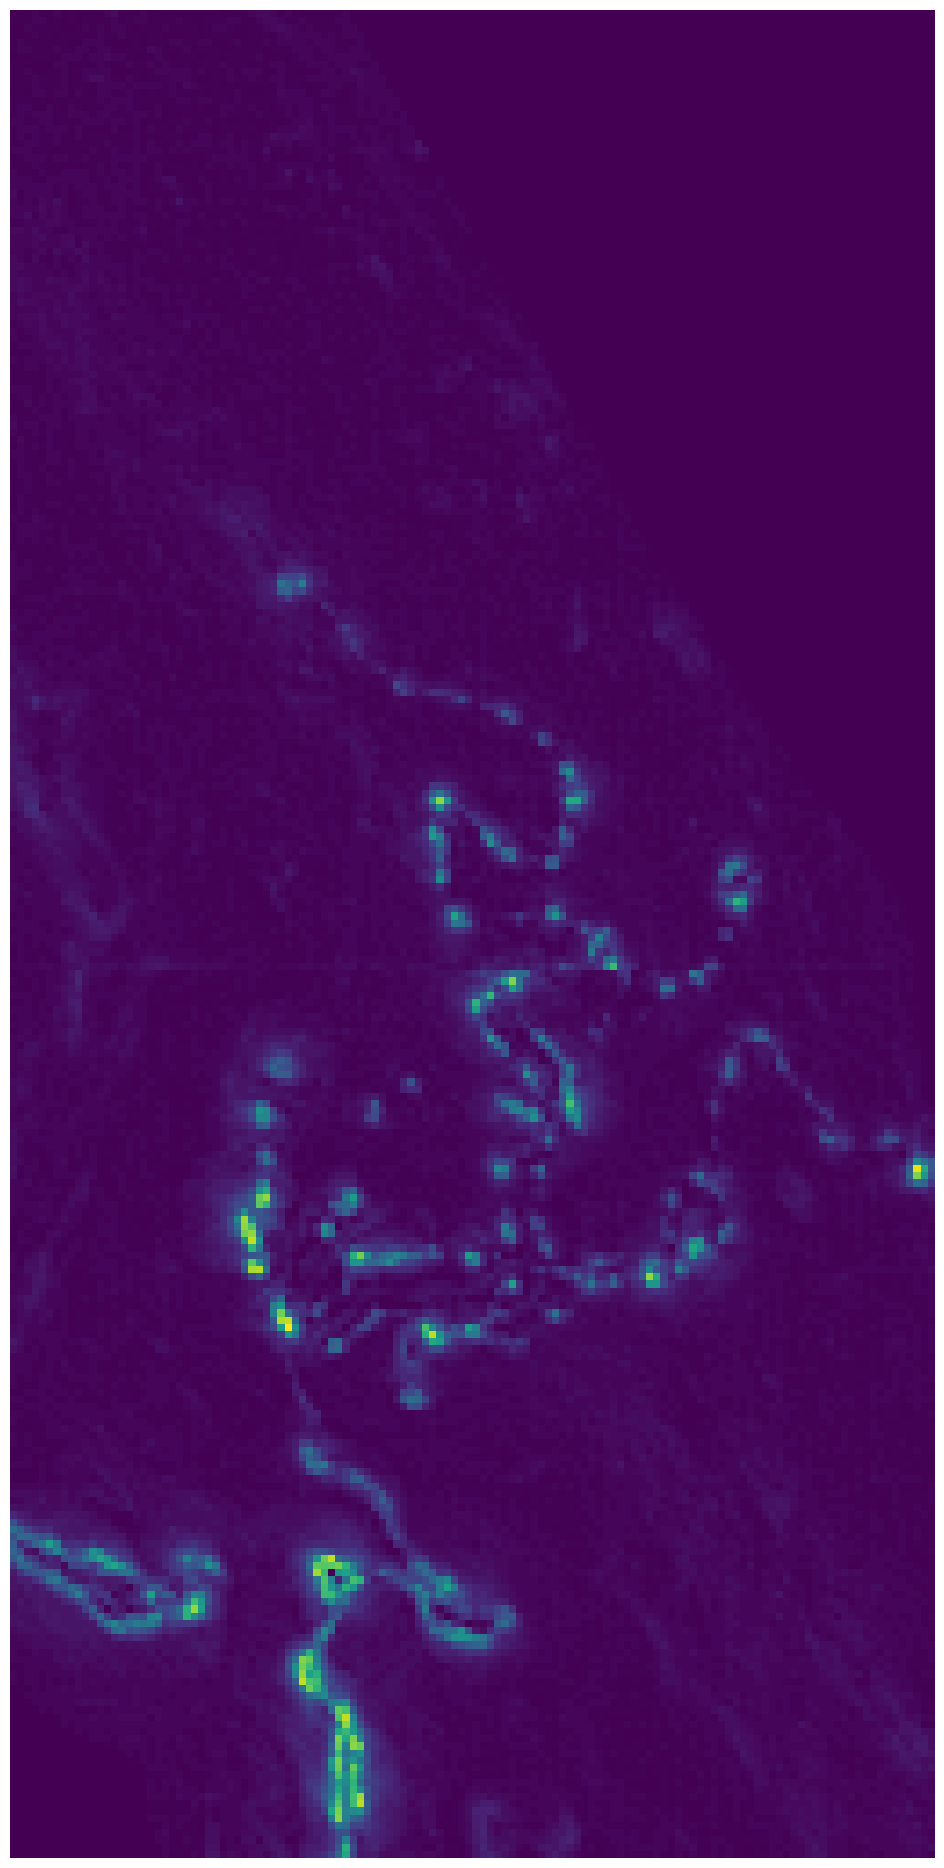

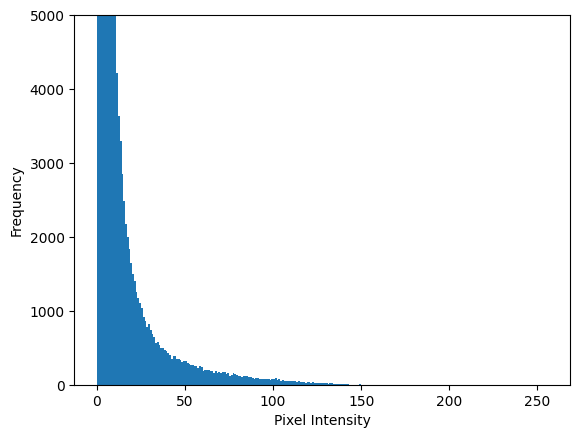

In [141]:




plt.figure(figsize=(24,24))
plt.imshow(orig_img[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W])
plt.axis('off')
plt.show()


plt.hist(orig_img.flatten(), bins=256, range=(0,256))
plt.ylim(0, 5000)
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.show()

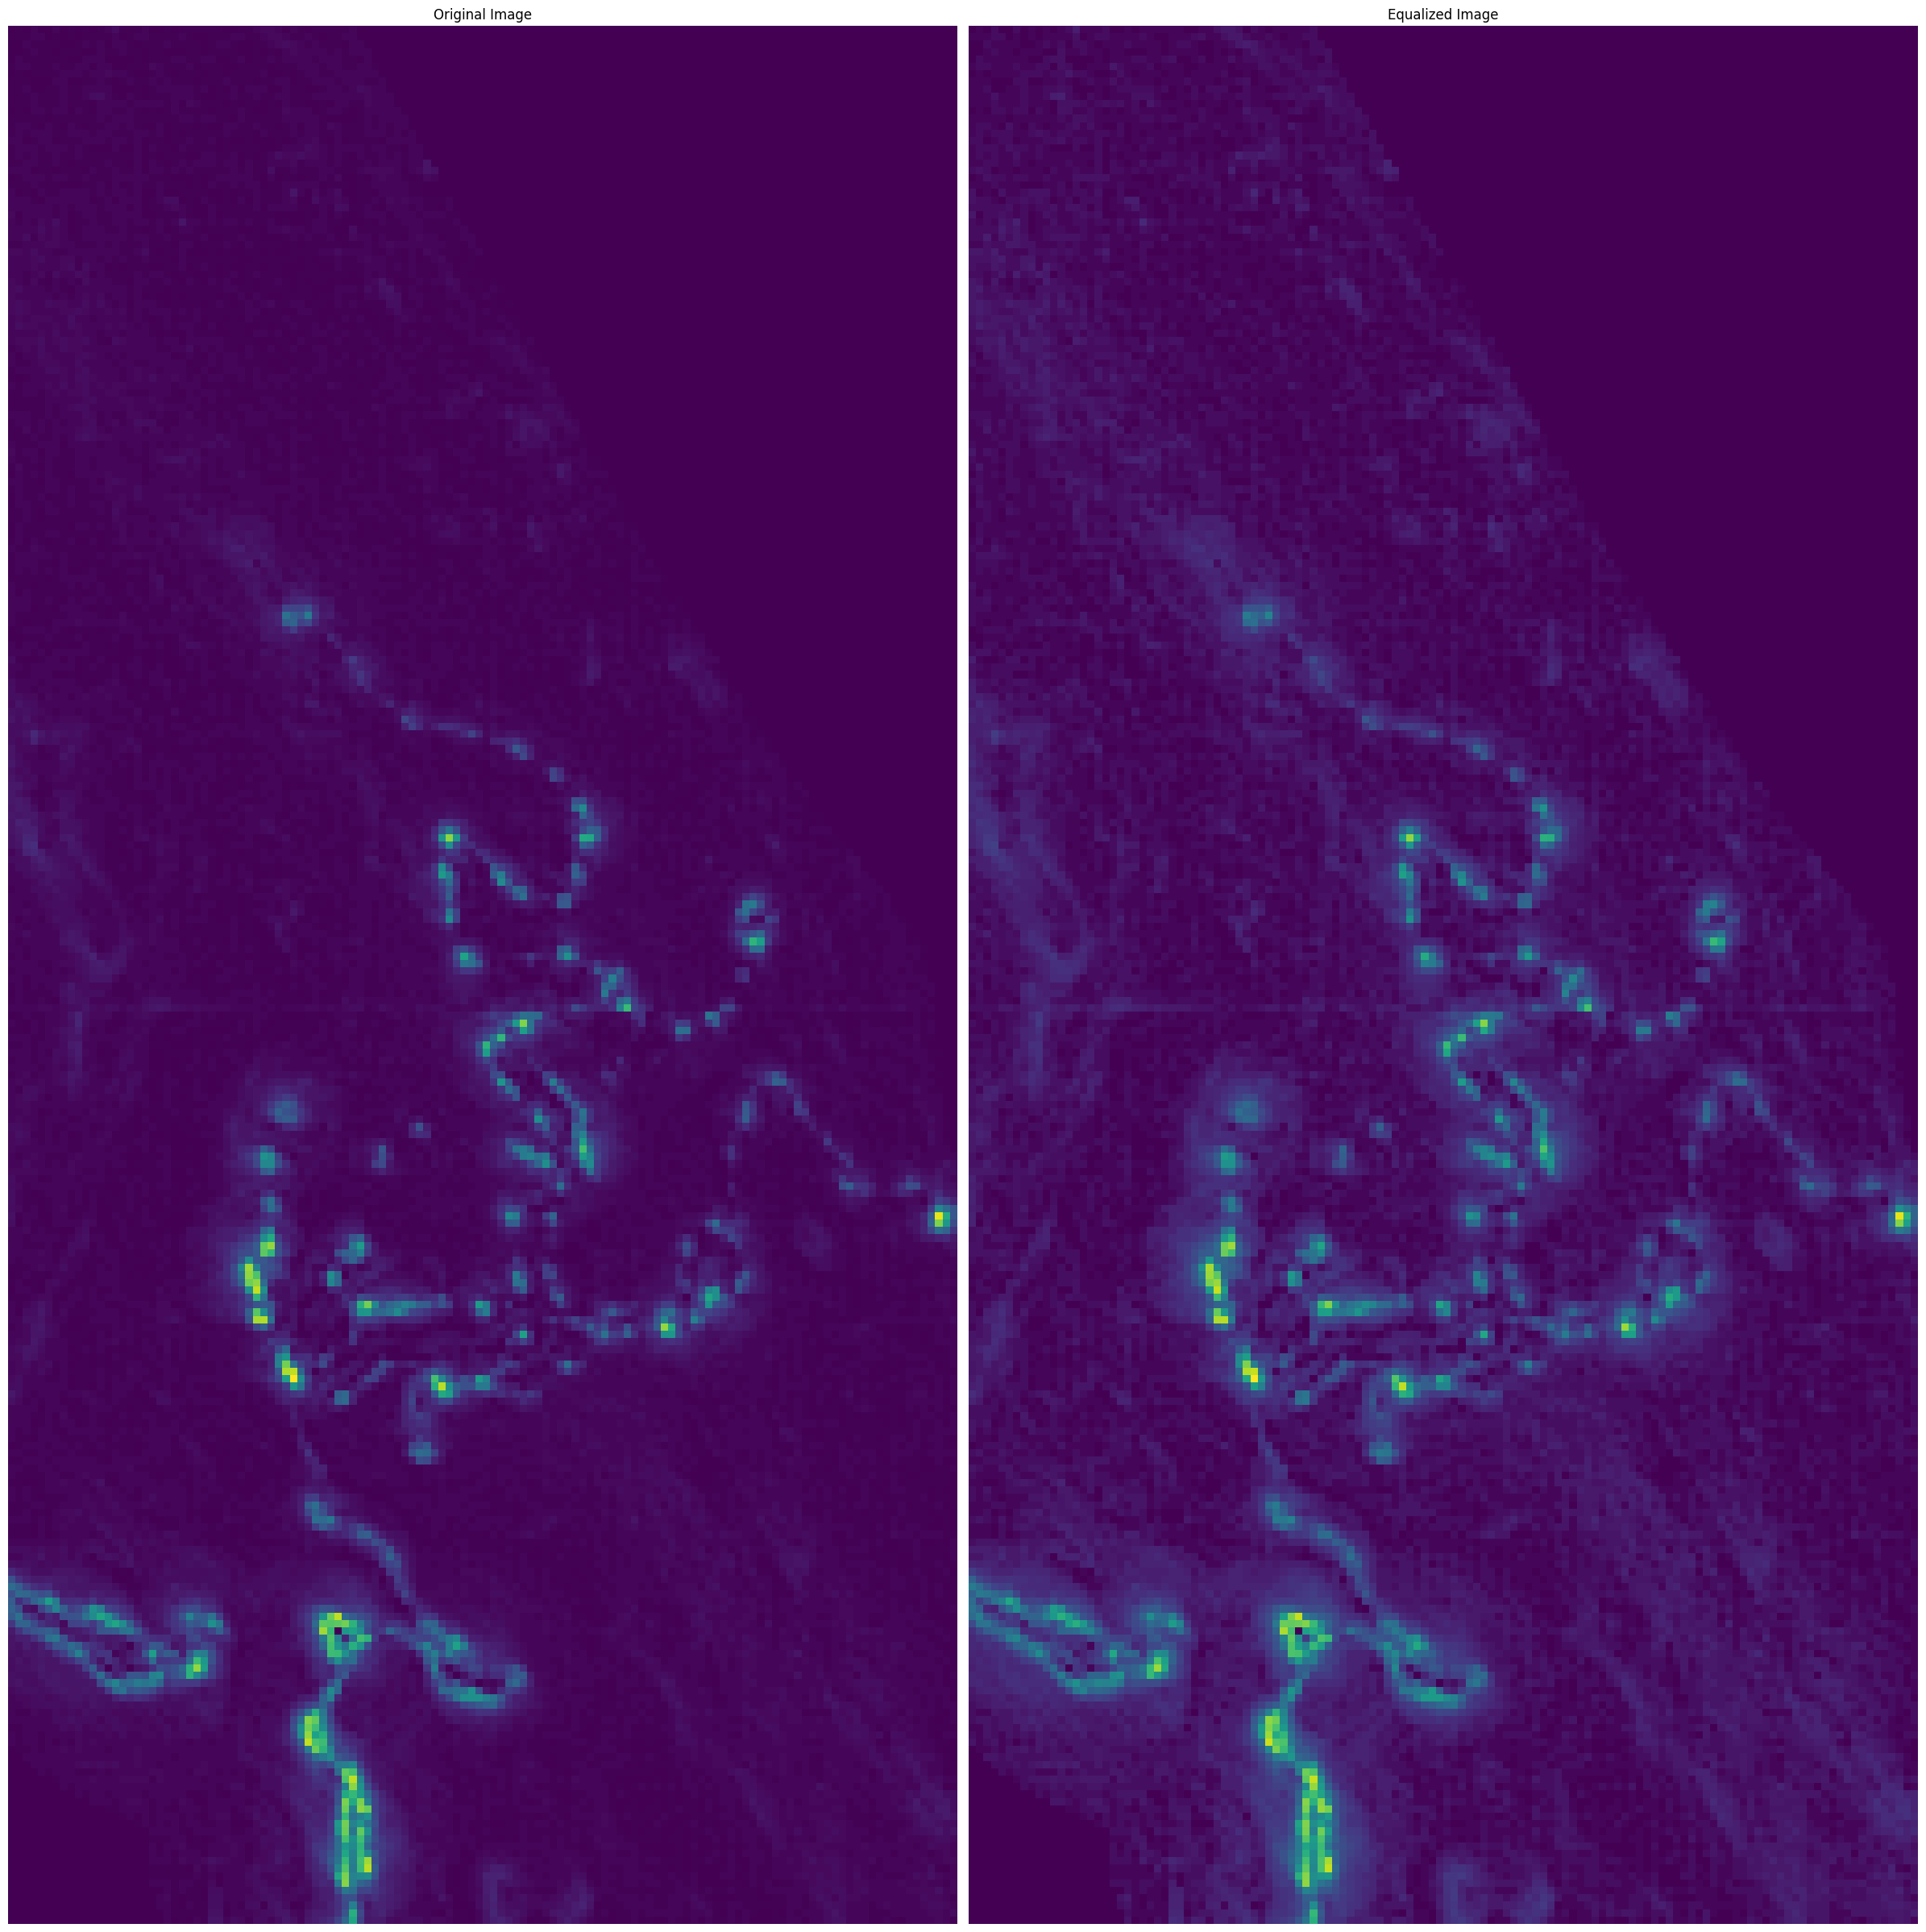

In [142]:

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
equalized_img = clahe.apply(orig_img)

# 比較原始圖像和均化後的圖像
fig, axes = plt.subplots(1, 2, figsize=(24, 24))

# 原始圖像
axes[0].imshow(orig_img[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W])
axes[0].set_title('Original Image')
axes[0].axis('off')

# 均化後的圖像
axes[1].imshow(equalized_img[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W])
axes[1].set_title('Equalized Image')
axes[1].axis('off')

plt.tight_layout()
plt.show()


/tmp/ipykernel_24075/2358467710.py:10: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  summary = summarize(skel_obj)


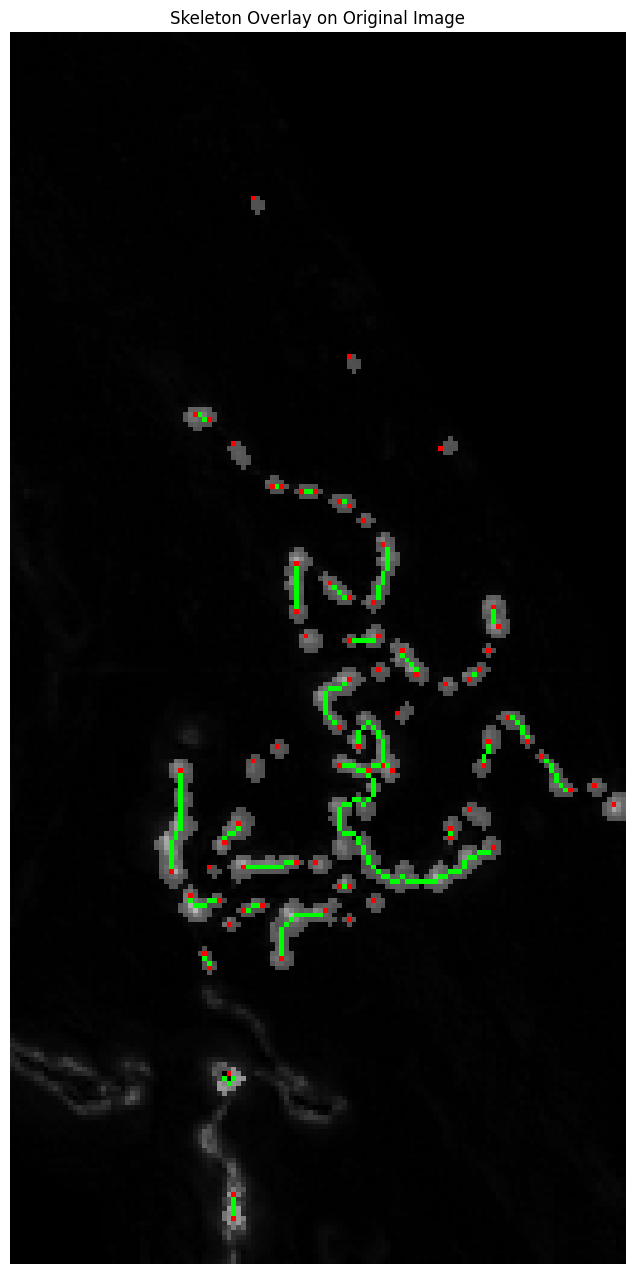

In [143]:
from skan import Skeleton, summarize
from skan.csr import skeleton_to_nx
from skimage import morphology
from skimage.measure import label, regionprops
import networkx as nx

binary = (annotation_img > 0).astype(np.uint8)
skeleton = morphology.skeletonize(binary).astype(np.uint8)
skel_obj = Skeleton(skeleton, keep_images=False)
summary = summarize(skel_obj)
skeleton_graph = skeleton_to_nx(skel_obj, summary=summary)
filtered_skeleton_graph = nx.MultiGraph()
# 過濾掉短邊
for u, v, data in skeleton_graph.edges(data=True):
    path = data['path']
    if len(path) > 2 or (skeleton_graph.degree(u) != 1 and skeleton_graph.degree(v) != 1): # 保留端點連接的短邊
        filtered_skeleton_graph.add_edge(u, v, **data)

# 將節點 id 轉回座標
mapping = {i: tuple(skel_obj.coordinates[i].astype(int)) for i in filtered_skeleton_graph.nodes()}
filtered_skeleton_graph = nx.relabel_nodes(filtered_skeleton_graph, mapping)

# 合併中間點
middle_points = [point for point in filtered_skeleton_graph.nodes() if len(list(filtered_skeleton_graph.neighbors(point))) == 2]
for mp in middle_points:
    neighbors = list(filtered_skeleton_graph.neighbors(mp))
    u, v = neighbors
    path1 = filtered_skeleton_graph[u][mp][0]['path']
    path2 = filtered_skeleton_graph[mp][v][0]['path']
    u_y, u_x = u
    mp_y, mp_x = mp
    v_y, v_x = v

    result_path = []
    if tuple(path1[-1]) ==  (mp_y, mp_x) and tuple(path1[0]) == (u_y, u_x):
        result_path.extend(path1)
    else:
        result_path.extend(path1[::-1])
    
    if tuple(path2[0]) == (mp_y, mp_x) and tuple(path2[-1]) == (v_y, v_x):
        result_path.extend(path2[1:])
    else:
        result_path.extend(path2[-2::-1])
    
    filtered_skeleton_graph.remove_node(mp)
    filtered_skeleton_graph.add_edge(u, v, path=result_path)


# 補齊缺失的節點
label_img = label(binary, connectivity=2)
regions = regionprops(label_img)
for region in regions:
    min_row, min_col, max_row, max_col = region.bbox
    bbox_nodes = [node for node in filtered_skeleton_graph.nodes() if node[0] >= min_row and node[0] < max_row and node[1] >= min_col and node[1] < max_col]
    if len(bbox_nodes) != 0:
        continue
    brightest_pixel = None
    brightest_value = -1
    
    avg_brightness = np.mean(equalized_img[min_row:max_row, min_col:max_col])
    # if avg_brightness < 20:
    #     continue

    for r in range(min_row, max_row):
        for c in range(min_col, max_col):
            if equalized_img[r, c] > brightest_value:
                brightest_value = equalized_img[r, c]
                brightest_pixel = (r, c)

    filtered_skeleton_graph.add_node(brightest_pixel)

viz_img = cv2.cvtColor(orig_img.copy(), cv2.COLOR_GRAY2BGR)
viz_img = cv2.addWeighted(viz_img, 0.7, cv2.cvtColor(annotation_img, cv2.COLOR_GRAY2BGR), 0.3, 0)

for u, v, data in filtered_skeleton_graph.edges(data=True):
    path = data['path']
    py = []
    px = []
    for y_i, x_i in path:
        viz_img[y_i, x_i] = [0, 255, 0]
for u in filtered_skeleton_graph.nodes():
    viz_img[u] = [255, 0, 0]  # 藍色標記骨架節點

plt.figure(figsize=(16, 16))
plt.imshow(viz_img[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W])
plt.title('Skeleton Overlay on Original Image')
plt.axis('off')
plt.show()


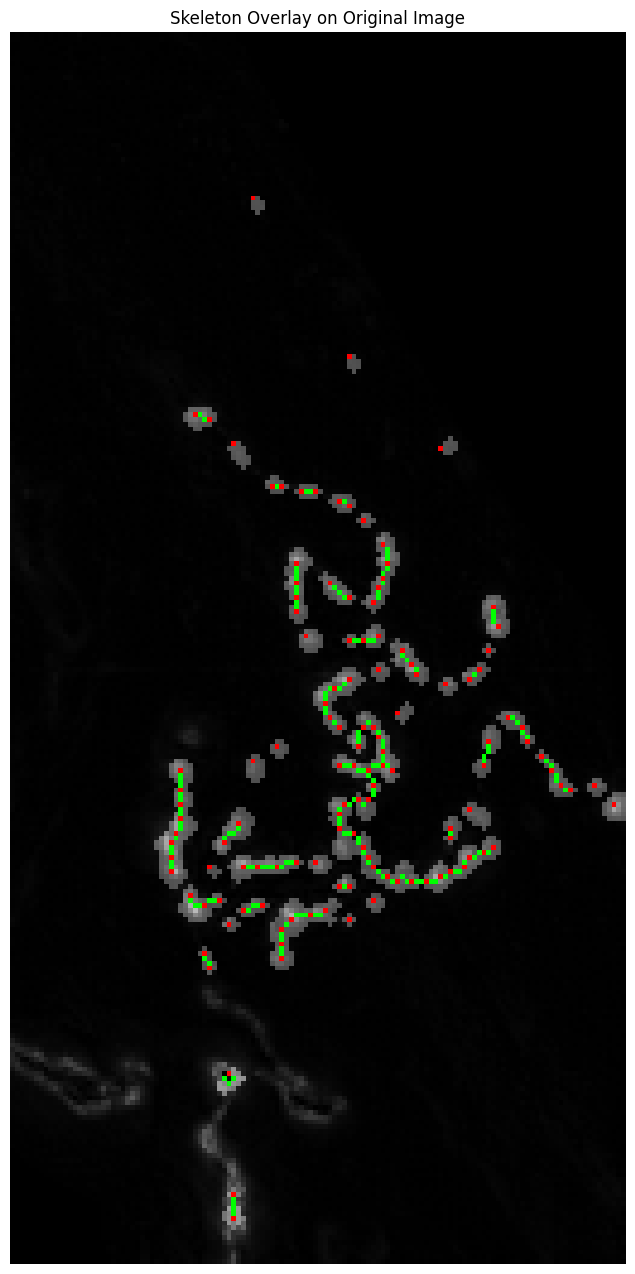

In [144]:
seed_graph = nx.MultiGraph()
segment_length = 3
for u in filtered_skeleton_graph.nodes():
    seed_graph.add_node(u)
for u, v ,data in filtered_skeleton_graph.edges(data=True):
    path = data['path']
    # 擺正方向
    corrected_path = path[:] if tuple(path[0]) == u and tuple(path[-1]) == v else path[::-1]
    path_arr = np.array(corrected_path)
    diffs = np.diff(path_arr, axis=0)
    distances = np.linalg.norm(diffs, axis=1)
    cumulative_distances = np.concatenate(([0], np.cumsum(distances)))
    path_length = cumulative_distances[-1]
    num_segments = int(path_length // segment_length)
    if num_segments <= 0:
        seed_graph.add_edge(u, v, path=path)
        continue
    
    last_index = 0
    for i in range(num_segments):
        target_distance = (i + 1) * path_length / num_segments
        segment_end_index = 0
        for idx , cumulative_distance in enumerate(cumulative_distances[last_index:]):
            if cumulative_distance >= target_distance:
                segment_end_index = idx + last_index
                break
        segment_path = corrected_path[last_index:segment_end_index + 1]
        if len(segment_path) == 0:
            continue
        seed_graph.add_edge(tuple(segment_path[0]), tuple(segment_path[-1]), path=segment_path)
        last_index = segment_end_index
    
    if last_index < len(corrected_path) - 1:
        final_segment_path = corrected_path[last_index:]
        seed_graph.add_edge(tuple(final_segment_path[0]), tuple(final_segment_path[-1]), path=final_segment_path)

viz_img = cv2.cvtColor(orig_img.copy(), cv2.COLOR_GRAY2BGR)
viz_img = cv2.addWeighted(viz_img, 0.7, cv2.cvtColor(annotation_img, cv2.COLOR_GRAY2BGR), 0.3, 0)

for u, v, data in seed_graph.edges(data=True):
    path = data['path']
    py = []
    px = []
    for y_i, x_i in path:
        viz_img[y_i, x_i] = [0, 255, 0]
for u in seed_graph.nodes():
    viz_img[u] = [255, 0, 0]  # 藍色標記骨架節點

plt.figure(figsize=(16, 16))
plt.imshow(viz_img[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W])
plt.title('Skeleton Overlay on Original Image')
plt.axis('off')
plt.show()


In [145]:
from scipy.spatial import KDTree
import networkx as nx
# 將 seed graph 中的 edge 加入低成本
for u, v, data in seed_graph.edges(data=True):
		data['weight'] = 1e-5  # 低成本

# 建構 KDTree
topology_points = np.array(seed_graph.nodes)
kdtree = KDTree(topology_points)

In [146]:
# 建立 seed pairing cost map
cost_map = ((255 - equalized_img.astype(np.float64)) / 255.0) ** 1.5
cost_map_h, cost_map_w = cost_map.shape
path_finding_bbox_padding = 10

seed_map = np.zeros_like(cost_map, dtype=np.uint8)
for p in topology_points:
    seed_map[p[0], p[1]] = True

path_lookup = {}
for u_idx in range(len(topology_points)):
	search_radius = 50
	# 在 KDTree 中搜尋鄰近點
	u = topology_points[u_idx]
    
    # 查詢半徑內的所有鄰居
	neighbor_indices = kdtree.query_ball_point(u, r=search_radius)
	targets = [topology_points[v_idx] for v_idx in neighbor_indices]

    # 排除自己
	targets = [target for target in targets if tuple(target) != tuple(u)]
	
	# 排除屬於同一個 component 的點
	current_component_id = label_img[u[0], u[1]]
	targets = [target for target in targets if label_img[target[0], target[1]] != current_component_id]
	
	# 排除已存在的配對
	targets = [target for target in targets if (tuple(u), tuple(target)) not in path_lookup and (tuple(target), tuple(u)) not in path_lookup]

	# 計算包含所有點的最小 bbox + padding
	all_points = [u] + targets
	all_y = [p[0] for p in all_points]
	all_x = [p[1] for p in all_points]

	min_y = max(0, min(all_y) - path_finding_bbox_padding)
	max_y = min(cost_map_h - 1, max(all_y) + path_finding_bbox_padding)
	min_x = max(0, min(all_x) - path_finding_bbox_padding)
	max_x = min(cost_map_w - 1, max(all_x) + path_finding_bbox_padding)

	cropped_cost_map = cost_map[min_y : max_y + 1, min_x : max_x + 1]

	local_points = [(pos_global[0] - min_y, pos_global[1] - min_x) for pos_global in all_points]
	mcp = ski.graph.MCP_Geometric(cropped_cost_map, fully_connected=True)
	cumulative_costs, traceback = mcp.find_costs(starts=local_points[:1], ends=local_points[1:])
	for target in local_points[1:]:
		if np.isinf(cumulative_costs[target]):
			continue

		path = mcp.traceback(target)
		cost = cumulative_costs[target]
		# 轉換回全局座標
		global_path = [(p[0] + min_y, p[1] + min_x) for p in path]
		global_start = (u[0], u[1])
		global_target = (target[0] + min_y, target[1] + min_x)
		normalized_cost = cost / 1
		
		middle_points = np.array(path[1:-1])
		if np.any(seed_map[middle_points[:, 0], middle_points[:, 1]]):
			continue

		if (global_target, global_start) in path_lookup:
			min_cost = min(path_lookup[(global_target, global_start)][1], normalized_cost)
			path_lookup[(global_target, global_start)] = (global_path, min_cost)
		else:
			path_lookup[(global_start, global_target)] = (global_path, normalized_cost)
	

In [147]:
from typing import List, Tuple, Dict, Optional
import numpy as np
import networkx as nx
from scipy.spatial import KDTree

# =============================================================================
# 輔助函數
# =============================================================================

def compute_vector_angle(v1: np.ndarray, v2: np.ndarray) -> float:
    """
    計算兩個向量之間的夾角（度）
    使用 dot product: cos(θ) = (v1·v2) / (|v1||v2|)
    
    Args:
        v1: 第一個向量
        v2: 第二個向量
    
    Returns:
        夾角 [0, 180] 度
    """
    # 計算向量長度
    norm1 = np.linalg.norm(v1)
    norm2 = np.linalg.norm(v2)
    
    # 避免除以零
    if norm1 < 1e-10 or norm2 < 1e-10:
        return 0.0
    
    # 計算 cos(θ)
    cos_angle = np.dot(v1, v2) / (norm1 * norm2)
    
    # 限制在 [-1, 1] 範圍內（處理浮點誤差）
    cos_angle = np.clip(cos_angle, -1.0, 1.0)
    
    # 轉換為角度
    angle = np.degrees(np.arccos(cos_angle))
    
    return angle


def is_direction_too_similar(
    new_direction: np.ndarray,
    existing_directions: List[np.ndarray],
    threshold_degrees: float
) -> bool:
    """
    檢查新方向是否與已存在的任一方向太相近
    
    Args:
        new_direction: 新候選的方向向量
        existing_directions: 已通過篩選的方向向量列表
        threshold_degrees: 角度閾值（度）
    
    Returns:
        True 如果太相近（應該跳過），False 如果可以考慮
    """
    if not existing_directions:
        return False
    
    for existing in existing_directions:
        angle = compute_vector_angle(new_direction, existing)
        if angle < threshold_degrees:
            return True
    
    return False


# =============================================================================
# 主要延伸函數
# =============================================================================

def extend_endpoints(
    graph: nx.Graph,
    kdtree: KDTree,
    path_lookup: Dict,
    search_radius: float,
    max_angle_penalty: float = 0.5,
    direction_threshold: float = 30.0,
) -> List[Tuple]:
    """
    對 graph 中所有端點（degree == 1）進行延伸
    
    Args:
        graph: NetworkX Graph，節點為座標 tuple (y, x)
        kdtree: 建立在 topology_points 上的 KDTree
        path_lookup: Dict[(coord1, coord2), (path_list, cost)]
        search_radius: KDTree 搜尋半徑
        max_angle_penalty: 最大角度懲罰 (0.5 = 50%)
        direction_threshold: 方向相似度閾值（度）
    
    Returns:
        new_edges: [(endpoint, target, cost, path), ...]
    """
    
	# 找出所有端點
    endpoints = {node for node in graph.nodes() if graph.degree(node) == 1}
    print(f"總端點數: {len(endpoints)}")
    
    new_edges = []
    
    for endpoint in endpoints:
        # 1. 取得端點的唯一鄰居，計算 BA 向量（延伸方向）
        neighbors = list(graph.neighbors(endpoint))
        if len(neighbors) != 1:
            continue
        
        neighbor = neighbors[0]
        extend_vector = np.array(endpoint) - np.array(neighbor)  # BA 向量
        
        # 2. KDTree 查詢候選節點
        endpoint_arr = np.array(endpoint)
        candidate_indices = kdtree.query_ball_point(endpoint_arr, r=search_radius)
        
        # 3. 計算每個候選的距離並排序（從近到遠）
        candidates_with_dist = []
        for idx in candidate_indices:
            candidate = tuple(topology_points[idx])
            # 排除自己和鄰居
            if candidate == endpoint or candidate == neighbor:
                continue
            # 排除已經在 graph 中連接的節點
            if graph.has_edge(endpoint, candidate):
                continue
            
            dist = np.linalg.norm(topology_points[idx] - endpoint_arr)
            candidates_with_dist.append((candidate, dist, idx))
        
        # 按距離排序（從近到遠）
        candidates_with_dist.sort(key=lambda x: x[1])
        
        # 4. 評估候選節點
        selected_directions = []  # 所有通過篩選的候選方向
        best_candidate = None
        best_cost = float("inf")
        best_path = None
        
        for candidate, dist, idx in candidates_with_dist:
            # 4.1 計算 AC 向量
            ac_vector = np.array(candidate) - endpoint_arr
            
            # 4.2 檢查方向是否與已通過篩選的候選方向太相近
            if is_direction_too_similar(ac_vector, selected_directions, direction_threshold):
                continue  
            
            # 4.3 通過篩選，立即加入方向清單
            selected_directions.append(ac_vector)
            
            # 4.4 計算 BA 與 AC 的夾角
            angle = compute_vector_angle(extend_vector, ac_vector)
            
            # 4.5 從 path_lookup 取得成本
            key1 = (endpoint, candidate)
            key2 = (candidate, endpoint)
            
            if key1 in path_lookup:
                path, base_cost = path_lookup[key1]
            elif key2 in path_lookup:
                path, base_cost = path_lookup[key2]
            else:
                continue  # 沒有路徑資料
            path_arr = np.array(path)
            diffs = np.diff(path_arr, axis=0)
            segment_dists = np.linalg.norm(diffs, axis=1)
            path_length = np.sum(segment_dists)
            normalized_cost = 0.8 *  base_cost / path_length + 0.2 * (dist / search_radius)
            
            if angle > 75:
                continue  
                        
            penalty = max_angle_penalty * (angle / 75) 
            final_cost = normalized_cost * (1 + penalty) / ( 1 + max_angle_penalty)
            
			# 4.7 更新最佳候選
            if final_cost < best_cost:
                best_cost = final_cost
                best_candidate = candidate
                best_path = path
        
        # 5. 記錄最佳延伸
        if best_candidate is not None:
            new_edges.append((endpoint, best_candidate, best_cost, best_path))
    
    return new_edges


new_edges = extend_endpoints(
    graph=seed_graph,
    kdtree=kdtree,
    path_lookup=path_lookup,
    search_radius=10,
    max_angle_penalty=0.5,
    direction_threshold=5.0,
)

print(f"\n找到 {len(new_edges)} 個可延伸的端點")



總端點數: 483

找到 247 個可延伸的端點


In [148]:
# 加入新邊到 graph
extended_graph = seed_graph.copy()
for endpoint, target, cost, path in new_edges:
    # if cost > 0.8:
    #     continue
    # if seed_graph.degree(endpoint) != 0 and seed_graph.degree(target) != 0:
    #     continue
    if not extended_graph.has_edge(endpoint, target):
        extended_graph.add_edge(endpoint, target, weight=cost, path=path)

print(f"延伸後總邊數: {extended_graph.number_of_edges()}")

# 檢查新的端點數量
new_endpoints = {node for node in extended_graph.nodes() if extended_graph.degree(node) == 1}
print(f"延伸後端點數: {len(new_endpoints)}")

延伸後總邊數: 707
延伸後端點數: 306


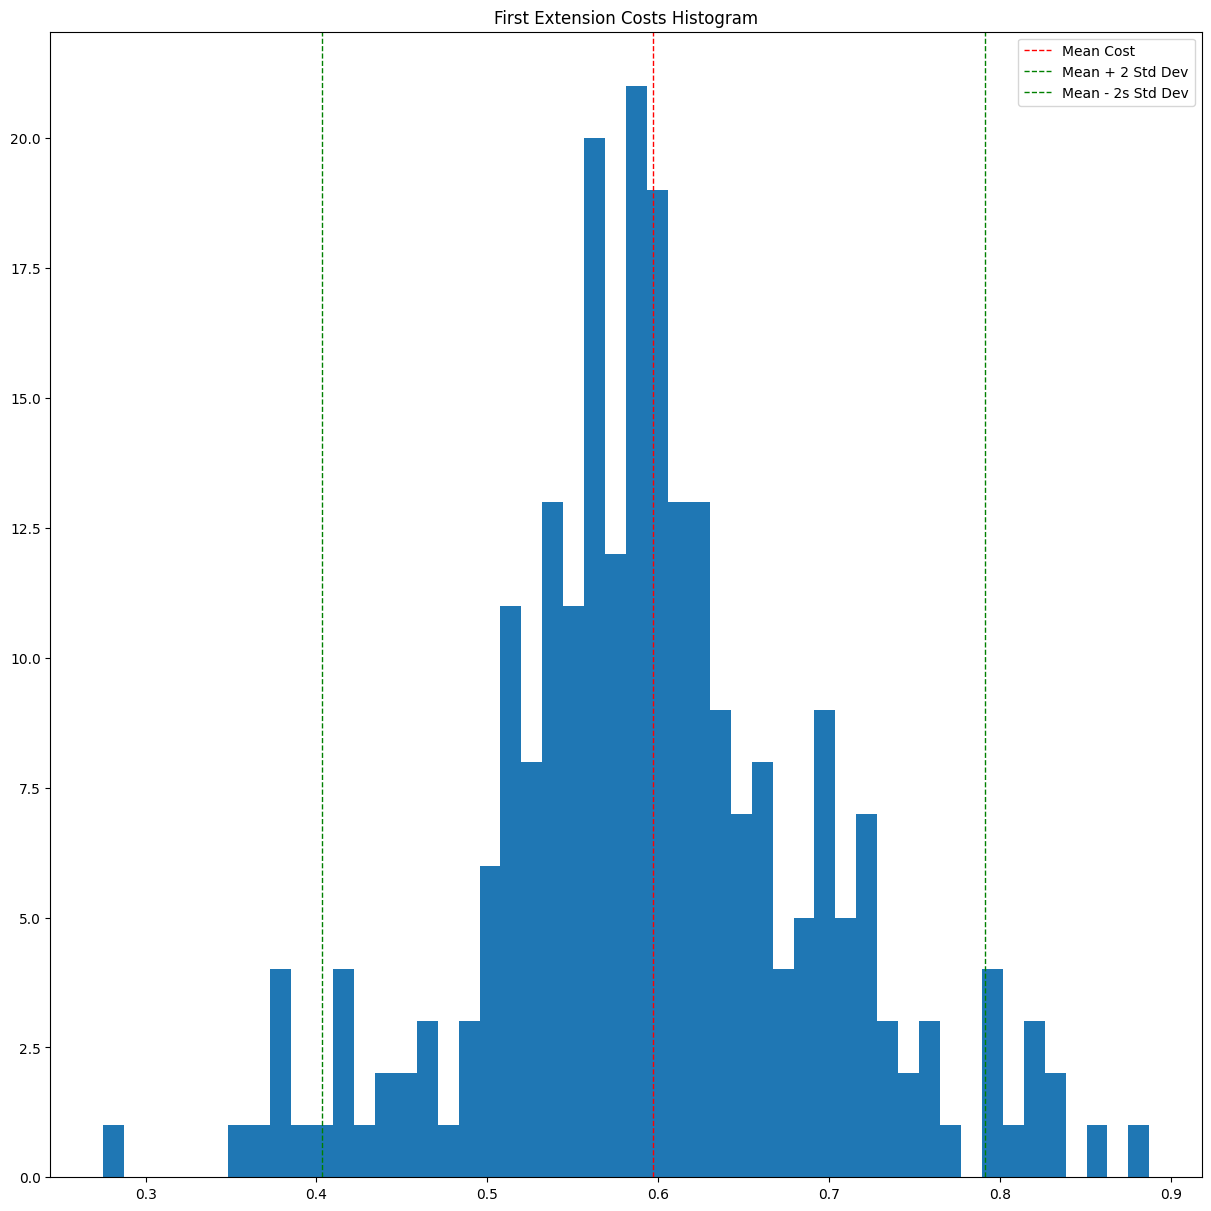

In [149]:
_, axes = plt.subplots(nrows=1, ncols=1, figsize=(12, 12), constrained_layout=True)
first_extend_costs = [cost for _, _, cost, _ in new_edges]

mean_cost = np.mean(first_extend_costs)
std_cost = np.std(first_extend_costs)
axes.hist(first_extend_costs, bins=50)
axes.set_title("First Extension Costs Histogram")
axes.axvline(mean_cost, color='r', linestyle='dashed', linewidth=1, label='Mean Cost')
axes.axvline(mean_cost + 2* std_cost, color='g', linestyle='dashed', linewidth=1, label='Mean + 2 Std Dev')
axes.axvline(mean_cost - 2* std_cost, color='g', linestyle='dashed', linewidth=1, label='Mean - 2s Std Dev')
axes.legend()
plt.show()

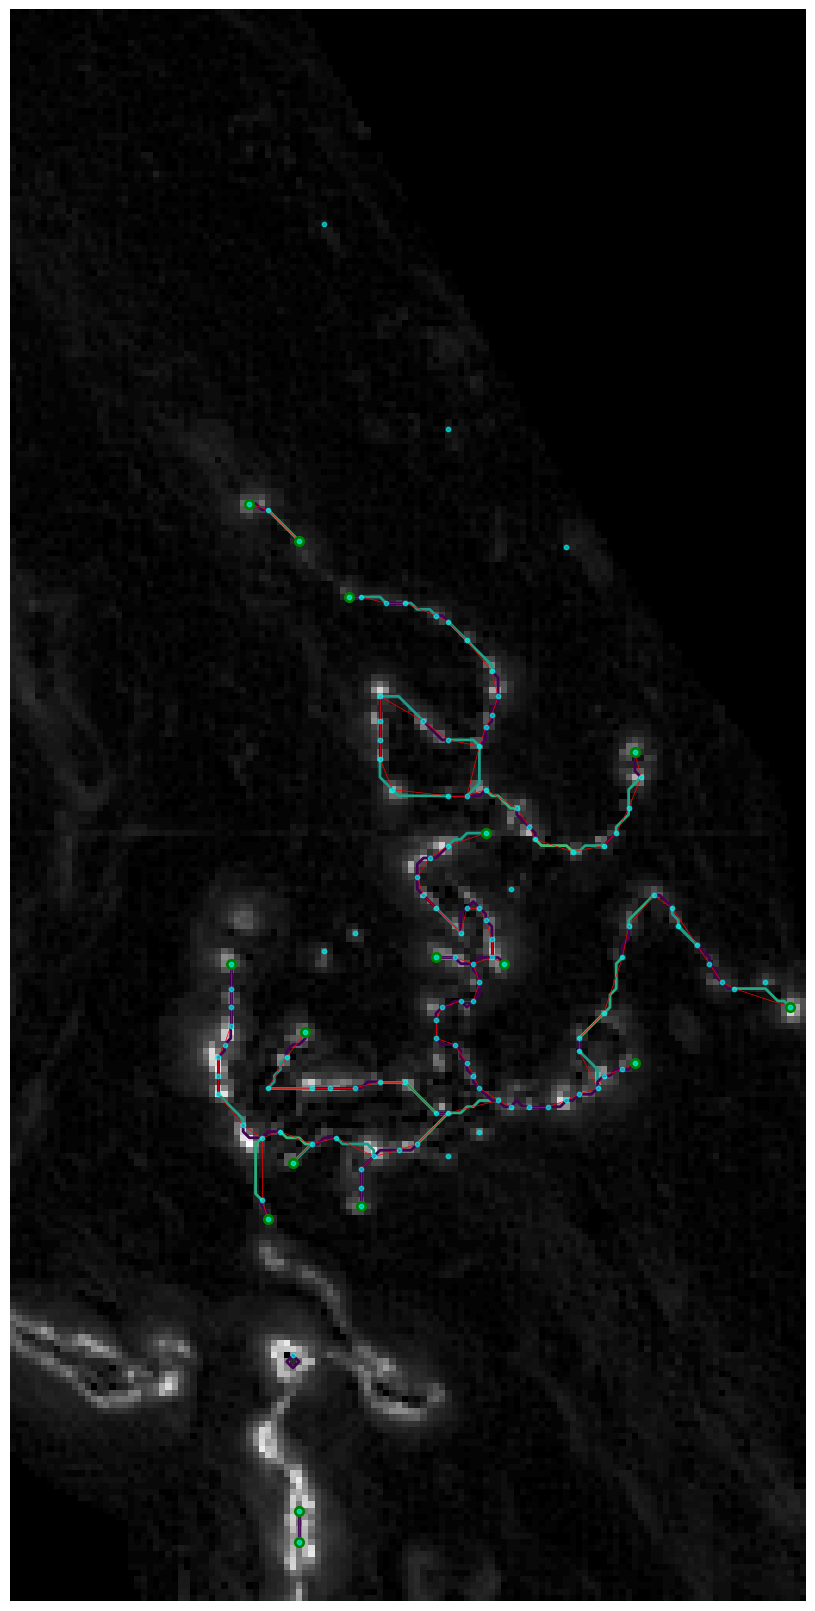

In [150]:
fig_size = 32
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(fig_size, fig_size // 2), constrained_layout=True)

# 繪製背景圖片
ax.imshow(equalized_img[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W], cmap='gray')



# 繪製所有連接路徑
# 使用成本來決定顏色（從藍色到紅色）
min_cost = 0
max_cost = 1

# 使用 colormap
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

norm = Normalize(vmin=min_cost, vmax=max_cost)
cmap = plt.cm.viridis  # 可以選擇其他 colormap: 'viridis', 'plasma', 'inferno', 'coolwarm'


for u, v, data in extended_graph.edges(data=True):
	path = data['path']
	cost = data['weight']
    
	# 繪製路徑
	roi_path = [(p[0], p[1]) for p in path if p[0] > ROI_Y and p[0] < ROI_Y + ROI_H and p[1] > ROI_X and p[1] < ROI_X + ROI_W]
	py = [p[0] - ROI_Y for p in roi_path]
	px = [p[1] - ROI_X for p in roi_path]
	
	# 根據成本決定顏色``
	color = cmap(norm(data.get('weight', 1.0)))
	ax.plot(px, py, color=color, alpha=1, linewidth=2)
	if len(roi_path) >= 2:
		ax.plot([px[0], px[-1]], [py[0], py[-1]], alpha=1, linewidth=0.5, color='red')
endpoints = [node for node in extended_graph.nodes() if extended_graph.degree(node) == 1]
for ep in endpoints:
	py, px = ep
	if py > ROI_Y and py < ROI_Y + ROI_H and px > ROI_X and px < ROI_X + ROI_W:
		ax.plot(px - ROI_X, py - ROI_Y, "go", markersize=7)
roi_seeds = [(s[0], s[1]) for s in seed_graph.nodes() if s[0] > ROI_Y and s[0] < ROI_Y + ROI_H and s[1] > ROI_X and s[1] < ROI_X + ROI_W]
seed_y = [s[0] - ROI_Y for s in roi_seeds]
seed_x = [s[1] - ROI_X for s in roi_seeds]
ax.scatter(seed_x, seed_y, c='cyan', s=10, alpha=0.6, zorder=2, label='Seeds')
ax.set_axis_off()

plt.show()

In [166]:
mst_tree = extended_graph.copy()

for _, _, data in mst_tree.edges(data=True):
  data['weight'] = data['weight'] * 0.5

In [167]:
# =============================================================================
# 階段2：為端點生成到所有節點的候選邊（用於MST）
# =============================================================================

def generate_endpoint_to_all_candidates(
    graph: nx.Graph,
    kdtree: KDTree,
    topology_points: np.ndarray,
    path_lookup: Dict,
    search_radius: float = 20,
    max_angle_degrees: float = 120,
    angle_penalty_weight: float = 0.3,
    distance_weight: float = 0.2,
) -> List[Tuple]:
    """
    為每個端點生成到所有其他節點的候選邊
    
    關鍵約束：
    - 一邊必須是端點 (degree == 1)
    - 另一邊可以是任意節點（端點或中間節點）
    - 加入角度懲罰（120度限制）
    
    Args:
        graph: 當前圖（包含階段1的邊）
        kdtree: 所有拓撲點的 KDTree
        topology_points: 所有拓撲點座標
        path_lookup: 預計算的路徑字典
        search_radius: 搜尋半徑（階段2用更大值，如20）
        max_angle_degrees: 最大允許角度（120度）
        angle_penalty_weight: 角度懲罰權重
        distance_weight: 距離懲罰權重
    
    Returns:
        [(endpoint, target_node, cost, path), ...]
    """
    # 找出所有端點
    endpoints = [node for node in graph.nodes() if graph.degree(node) == 1]
    print(f"階段2：找到 {len(endpoints)} 個端點")
    
    candidate_edges = []
    
    for endpoint in endpoints:
        # 取得端點的鄰居，計算延伸方向
        neighbors = list(graph.neighbors(endpoint))
        if len(neighbors) != 1:
            continue
        
        neighbor = neighbors[0]
        extend_vector = np.array(endpoint) - np.array(neighbor)
        
        # 在 KDTree 中搜尋所有候選節點
        endpoint_arr = np.array(endpoint)
        candidate_indices = kdtree.query_ball_point(endpoint_arr, r=search_radius)
        
        for candidate_idx in candidate_indices:
            target_node = tuple(topology_points[candidate_idx])
            
            # 排除自己和鄰居
            if target_node == endpoint or target_node == neighbor:
                continue
            
            # 排除已存在的連接
            if graph.has_edge(endpoint, target_node):
                continue
            
            # 計算距離和角度
            ac_vector = np.array(target_node) - endpoint_arr
            distance = np.linalg.norm(ac_vector)
            angle = compute_vector_angle(extend_vector, ac_vector)
            
            # 角度限制：120度（比階段1的75度寬鬆）
            if angle > max_angle_degrees:
                continue
            
            # 查找路徑
            path = None
            base_cost = None
            
            if (endpoint, target_node) in path_lookup:
                path, base_cost = path_lookup[(endpoint, target_node)]
            elif (target_node, endpoint) in path_lookup:
                path, base_cost = path_lookup[(target_node, endpoint)]
            else:
                continue
            
            # 計算路徑長度
            path_arr = np.array(path)
            diffs = np.diff(path_arr, axis=0)
            segment_dists = np.linalg.norm(diffs, axis=1)
            path_length = np.sum(segment_dists)
            
            # 計算最終成本
            distance_penalty = distance / search_radius
            normalized_cost =  (1-distance_weight)*  base_cost / path_length + distance_weight * distance_penalty
            angle_penalty = angle_penalty_weight * (angle / 180.0)
            
            final_cost = normalized_cost * ( 1 + angle_penalty) / (1 + angle_penalty_weight)
            
            candidate_edges.append((endpoint, target_node, final_cost, path))
    
    # 統計目標節點類型
    target_endpoints = sum(1 for _, target, _, _ in candidate_edges 
                          if graph.degree(target) == 1)
    target_middle = sum(1 for _, target, _, _ in candidate_edges 
                       if graph.degree(target) >= 2)
    
    print(f"生成 {len(candidate_edges)} 條候選邊")
    print(f"  - 端點→端點: {target_endpoints}")
    print(f"  - 端點→中間節點: {target_middle}")
    
    return candidate_edges


# 執行階段2：生成候選邊
print("=" * 60)
print("階段2：生成 MST 候選邊（半徑=20，角度≤120°）")
print("=" * 60)

phase2_candidates = generate_endpoint_to_all_candidates(
    graph=mst_tree,
    kdtree=kdtree,
    topology_points=topology_points,
    path_lookup=path_lookup,
    search_radius=20,          # 更大半徑
    max_angle_degrees=90,     # 更寬鬆角度
    angle_penalty_weight=0.5,  # 角度懲罰
    distance_weight=0.2,       # 距離懲罰
)

# 記錄階段1的邊數（用於後續分析）
phase1_edge_count = mst_tree.number_of_edges()
print(f"\n當前 mst_tree 狀態:")
print(f"  - 階段1邊數（已折扣0.5×）: {phase1_edge_count}")
print(f"  - 節點數: {mst_tree.number_of_nodes()}")


階段2：生成 MST 候選邊（半徑=20，角度≤120°）
階段2：找到 306 個端點
生成 548 條候選邊
  - 端點→端點: 166
  - 端點→中間節點: 238

當前 mst_tree 狀態:
  - 階段1邊數（已折扣0.5×）: 707
  - 節點數: 1086


In [168]:
# =============================================================================
# 將階段2候選邊加入 mst_tree 並執行 MST
# =============================================================================

print("\n" + "=" * 60)
print("將階段2候選邊加入 mst_tree")
print("=" * 60)

# 標記階段1的邊（用於後續分析）
for u, v, data in mst_tree.edges(data=True):
    data['phase'] = 1

# 加入階段2的候選邊（不折扣，原始成本）
added_count = 0
for endpoint, target, cost, path in phase2_candidates:
    if cost > 0.75:
        continue
    if not mst_tree.has_edge(endpoint, target):
        mst_tree.add_edge(endpoint, target, weight=cost, path=path, phase=2)
        added_count += 1

print(f"✓ 加入 {added_count} 條階段2候選邊")
print(f"✓ mst_tree 總邊數: {mst_tree.number_of_edges()}")
print(f"  - 階段1（0.5× 成本）: {phase1_edge_count}")
print(f"  - 階段2（1.0× 成本）: {added_count}")

# 執行 MST
print("\n" + "=" * 60)
print("執行最小生成樹 (MST)")
print("=" * 60)

mst_result = nx.minimum_spanning_tree(mst_tree, weight='weight')

# 分析 MST 結果
phase1_in_mst = sum(1 for u, v in mst_result.edges() 
                    if mst_result[u][v].get('phase') == 1)
phase2_in_mst = sum(1 for u, v in mst_result.edges() 
                    if mst_result[u][v].get('phase') == 2)

print(f"\nMST 結果:")
print(f"  - 總邊數: {mst_result.number_of_edges()}")
print(f"  - 來自階段1: {phase1_in_mst} / {phase1_edge_count} ({phase1_in_mst/phase1_edge_count*100:.1f}% 保留)")
print(f"  - 來自階段2: {phase2_in_mst} / {added_count} ({phase2_in_mst/added_count*100:.1f}% 選中)")
print(f"  - 剩餘端點數: {sum(1 for n in mst_result.nodes() if mst_result.degree(n) == 1)}")

# 分析階段2選中的邊的連接類型
print("\n階段2選中的邊分析:")
endpoint_to_endpoint = 0
endpoint_to_middle = 0

for u, v, data in mst_result.edges(data=True):
    if data.get('phase') == 2:
        # 檢查在階段1圖中 u 和 v 的度數
        # 需要用 extended_graph（階段1的原始圖）來判斷
        deg_u = extended_graph.degree(u)
        deg_v = extended_graph.degree(v)
        
        if deg_u == 1 and deg_v == 1:
            endpoint_to_endpoint += 1
        elif deg_u == 1 or deg_v == 1:
            endpoint_to_middle += 1

print(f"  - 端點→端點: {endpoint_to_endpoint}")
print(f"  - 端點→中間節點: {endpoint_to_middle}")



將階段2候選邊加入 mst_tree
✓ 加入 497 條階段2候選邊
✓ mst_tree 總邊數: 1204
  - 階段1（0.5× 成本）: 707
  - 階段2（1.0× 成本）: 497

執行最小生成樹 (MST)

MST 結果:
  - 總邊數: 865
  - 來自階段1: 0 / 707 (0.0% 保留)
  - 來自階段2: 0 / 497 (0.0% 選中)
  - 剩餘端點數: 272

階段2選中的邊分析:
  - 端點→端點: 31
  - 端點→中間節點: 145


/tmp/ipykernel_24075/1945564163.py:100: UserWarning: Glyph 38542 (\N{CJK UNIFIED IDEOGRAPH-968E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24075/1945564163.py:100: UserWarning: Glyph 27573 (\N{CJK UNIFIED IDEOGRAPH-6BB5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24075/1945564163.py:100: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24075/1945564163.py:100: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24075/1945564163.py:100: UserWarning: Glyph 20449 (\N{CJK UNIFIED IDEOGRAPH-4FE1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24075/1945564163.py:100: UserWarning: Glyph 24515 (\N{CJK UNIFIED IDEOGRAPH-5FC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24075/1945564163.py:100: UserWarning: Glyph 36899 (\N{CJK UNIFIED IDEOGRAPH-90

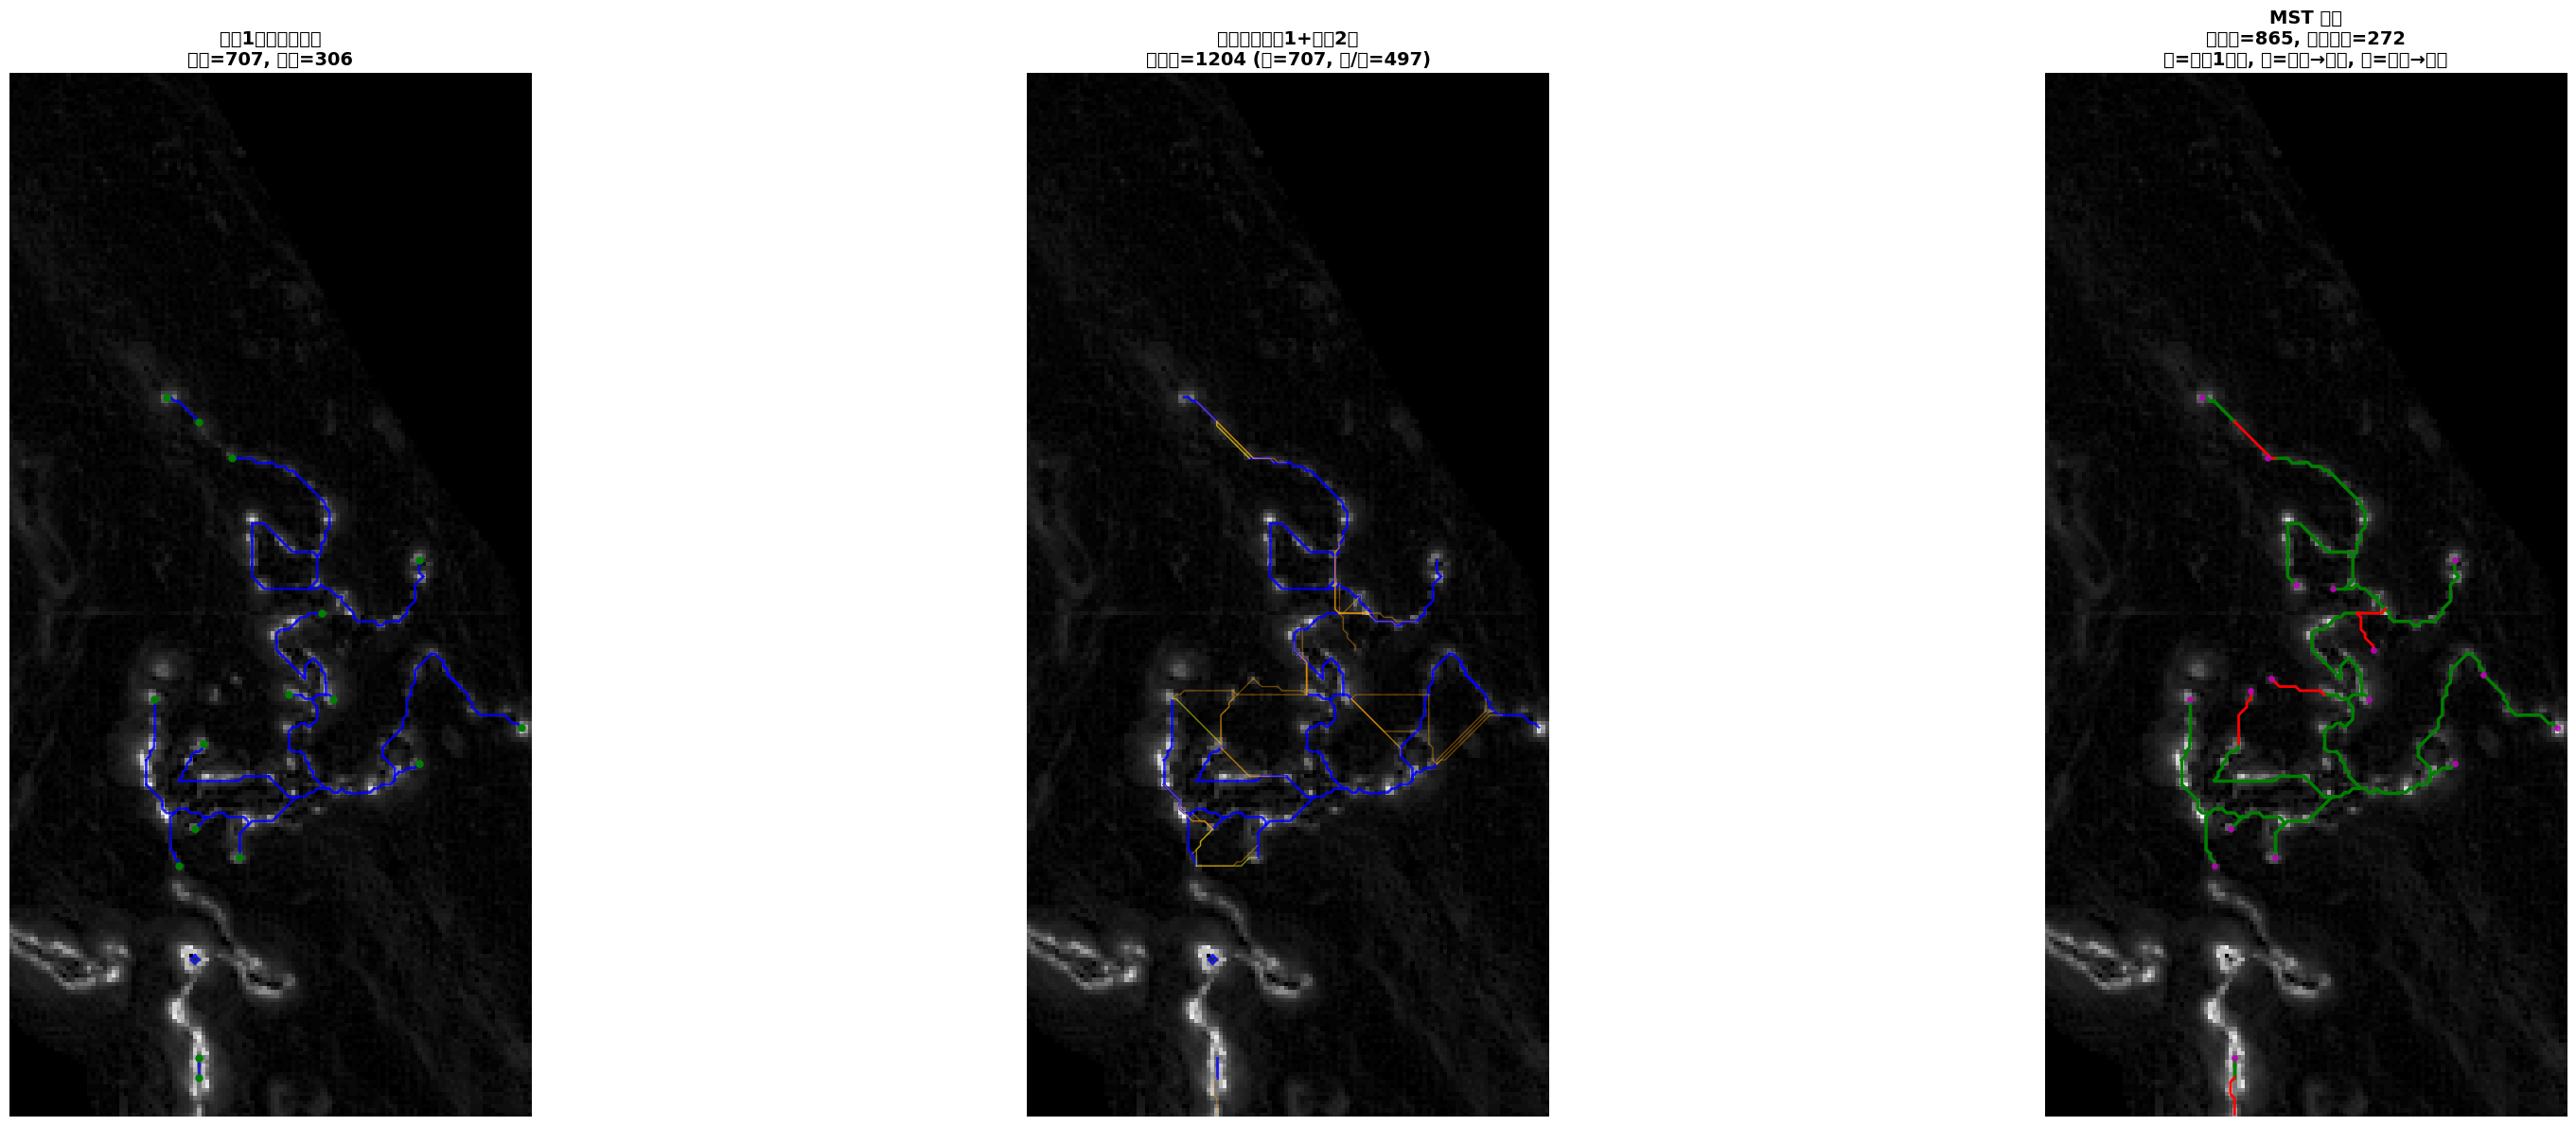


詳細統計
階段1 → MST 保留率: 0/707 = 0.0%
階段2 → MST 選中率: 0/497 = 0.0%
端點減少: 306 → 272 (34 個端點被連接)


In [169]:
# =============================================================================
# 可視化結果
# =============================================================================

def plot_edge_in_roi(ax, path, color, linewidth=2, alpha=1.0):
    """在 ROI 中繪製邊"""
    roi_path = [(p[0], p[1]) for p in path 
                if ROI_Y < p[0] < ROI_Y + ROI_H and ROI_X < p[1] < ROI_X + ROI_W]
    if len(roi_path) >= 2:
        py = [p[0] - ROI_Y for p in roi_path]
        px = [p[1] - ROI_X for p in roi_path]
        ax.plot(px, py, color=color, linewidth=linewidth, alpha=alpha)

# 創建三個子圖
fig, axes = plt.subplots(1, 3, figsize=(36, 12))

# ============= 左圖：階段1（extended_graph）=============
ax = axes[0]
ax.imshow(equalized_img[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W], cmap='gray')

# 繪製階段1的邊（藍色）
for u, v, data in extended_graph.edges(data=True):
    plot_edge_in_roi(ax, data['path'], 'blue', linewidth=2, alpha=0.8)

# 標記端點（綠色）
endpoints_phase1 = [n for n in extended_graph.nodes() if extended_graph.degree(n) == 1]
for ep in endpoints_phase1:
    if ROI_Y < ep[0] < ROI_Y + ROI_H and ROI_X < ep[1] < ROI_X + ROI_W:
        ax.plot(ep[1] - ROI_X, ep[0] - ROI_Y, 'go', markersize=5)

ax.set_title(f'階段1：高信心連接\n邊數={extended_graph.number_of_edges()}, 端點={len(endpoints_phase1)}', 
             fontsize=14, fontweight='bold')
ax.axis('off')

# ============= 中圖：候選圖（mst_tree）=============
ax = axes[1]
ax.imshow(equalized_img[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W], cmap='gray')

# 繪製階段1的邊（藍色）
for u, v, data in mst_tree.edges(data=True):
    if data.get('phase') == 1:
        plot_edge_in_roi(ax, data['path'], 'blue', linewidth=2, alpha=0.8)

# 繪製階段2的候選邊
for u, v, data in mst_tree.edges(data=True):
    if data.get('phase') == 2:
        # 根據連接類型選擇顏色
        deg_u = extended_graph.degree(u)
        deg_v = extended_graph.degree(v)
        
        if deg_u == 1 and deg_v == 1:
            color = 'yellow'  # 端點→端點
            alpha = 0.5
        else:
            color = 'orange'  # 端點→中間節點
            alpha = 0.4
        
        plot_edge_in_roi(ax, data['path'], color, linewidth=1, alpha=alpha)

ax.set_title(f'候選圖（階段1+階段2）\n總邊數={mst_tree.number_of_edges()} (藍={phase1_edge_count}, 黃/橙={added_count})', 
             fontsize=14, fontweight='bold')
ax.axis('off')

# ============= 右圖：MST 結果 =============
ax = axes[2]
ax.imshow(equalized_img[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W], cmap='gray')

# 繪製 MST 的邊
for u, v, data in mst_result.edges(data=True):
    if data.get('phase') == 1:
        # 階段1的邊（綠色，粗）
        color = 'green'
        linewidth = 2.5
        alpha = 1.0
    else:
        # 階段2的邊，根據連接類型區分
        deg_u = extended_graph.degree(u)
        deg_v = extended_graph.degree(v)
        
        if deg_u == 1 and deg_v == 1:
            color = 'cyan'  # 端點→端點
            linewidth = 2
        else:
            color = 'red'  # 端點→中間節點
            linewidth = 2
        alpha = 1.0
    
    plot_edge_in_roi(ax, data['path'], color, linewidth=linewidth, alpha=alpha)

# 標記剩餘端點
endpoints_mst = [n for n in mst_result.nodes() if mst_result.degree(n) == 1]
for ep in endpoints_mst:
    if ROI_Y < ep[0] < ROI_Y + ROI_H and ROI_X < ep[1] < ROI_X + ROI_W:
        ax.plot(ep[1] - ROI_X, ep[0] - ROI_Y, 'mo', markersize=4, alpha=0.8)

ax.set_title(f'MST 結果\n總邊數={mst_result.number_of_edges()}, 剩餘端點={len(endpoints_mst)}\n綠=階段1保留, 青=端點→端點, 紅=端點→中間', 
             fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.show()

# 打印詳細統計
print("\n" + "=" * 60)
print("詳細統計")
print("=" * 60)
print(f"階段1 → MST 保留率: {phase1_in_mst}/{phase1_edge_count} = {phase1_in_mst/phase1_edge_count*100:.1f}%")
print(f"階段2 → MST 選中率: {phase2_in_mst}/{added_count} = {phase2_in_mst/added_count*100:.1f}%")
print(f"端點減少: {len(endpoints_phase1)} → {len(endpoints_mst)} ({len(endpoints_phase1) - len(endpoints_mst)} 個端點被連接)")


成本分析
階段1: mean=0.597, std=0.097
階段2: mean=0.660, std=0.094
  - 端點→端點: mean=0.657, n=203
  - 端點→中間: mean=0.661, n=510


/tmp/ipykernel_24075/3579046615.py:111: UserWarning: Glyph 38542 (\N{CJK UNIFIED IDEOGRAPH-968E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24075/3579046615.py:111: UserWarning: Glyph 27573 (\N{CJK UNIFIED IDEOGRAPH-6BB5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24075/3579046615.py:111: UserWarning: Glyph 20505 (\N{CJK UNIFIED IDEOGRAPH-5019}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24075/3579046615.py:111: UserWarning: Glyph 36984 (\N{CJK UNIFIED IDEOGRAPH-9078}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24075/3579046615.py:111: UserWarning: Glyph 37002 (\N{CJK UNIFIED IDEOGRAPH-908A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24075/3579046615.py:111: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24075/3579046615.py:111: UserWarning: Glyph 26412 (\N{CJK UNIFIED I

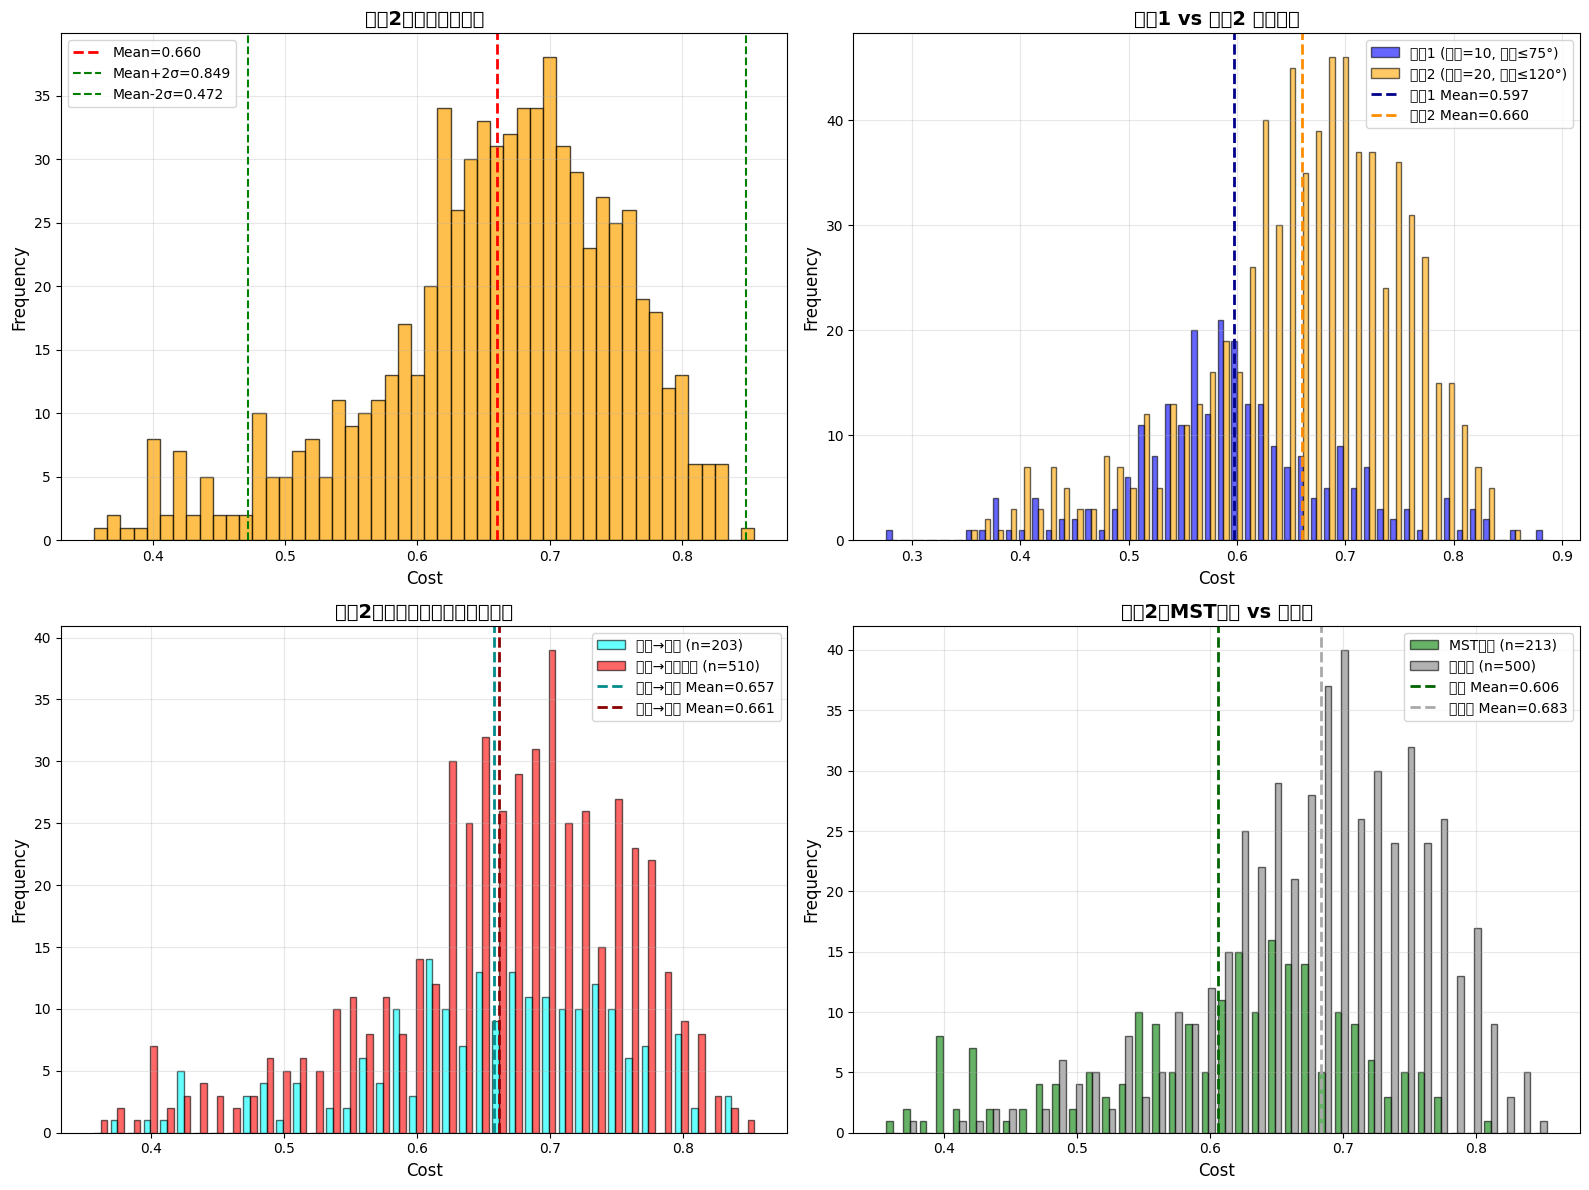


MST 選擇偏好分析
選中的邊平均成本: 0.606
未選中的邊平均成本: 0.683
成本差異: 0.077 (12.7%)


In [161]:
# =============================================================================
# 階段2 成本分析
# =============================================================================

# 收集階段2候選邊的成本
phase2_costs = [cost for _, _, cost, _ in phase2_candidates]

# 分類：端點→端點 vs 端點→中間節點
endpoint_to_endpoint_costs = []
endpoint_to_middle_costs = []

for endpoint, target, cost, path in phase2_candidates:
    deg_target = extended_graph.degree(target)
    if deg_target == 1:
        endpoint_to_endpoint_costs.append(cost)
    else:
        endpoint_to_middle_costs.append(cost)

# 階段1成本（參考）
phase1_costs = first_extend_costs  # 來自之前的 Cell

# 計算統計量
phase2_mean = np.mean(phase2_costs)
phase2_std = np.std(phase2_costs)
phase1_mean = np.mean(phase1_costs)
phase1_std = np.std(phase1_costs)

print("=" * 60)
print("成本分析")
print("=" * 60)
print(f"階段1: mean={phase1_mean:.3f}, std={phase1_std:.3f}")
print(f"階段2: mean={phase2_mean:.3f}, std={phase2_std:.3f}")
print(f"  - 端點→端點: mean={np.mean(endpoint_to_endpoint_costs):.3f}, n={len(endpoint_to_endpoint_costs)}")
print(f"  - 端點→中間: mean={np.mean(endpoint_to_middle_costs):.3f}, n={len(endpoint_to_middle_costs)}")

# 創建 2x2 子圖
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ============= 左上：階段2 總成本分布 =============
ax = axes[0, 0]
ax.hist(phase2_costs, bins=50, alpha=0.7, color='orange', edgecolor='black')
ax.axvline(phase2_mean, color='r', linestyle='--', linewidth=2, label=f'Mean={phase2_mean:.3f}')
ax.axvline(phase2_mean + 2*phase2_std, color='g', linestyle='--', linewidth=1.5, 
           label=f'Mean+2σ={phase2_mean + 2*phase2_std:.3f}')
ax.axvline(phase2_mean - 2*phase2_std, color='g', linestyle='--', linewidth=1.5,
           label=f'Mean-2σ={phase2_mean - 2*phase2_std:.3f}')
ax.set_xlabel('Cost', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('階段2候選邊成本分布', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# ============= 右上：階段1 vs 階段2 對比 =============
ax = axes[0, 1]
ax.hist([phase1_costs, phase2_costs], bins=50, alpha=0.6, 
        label=['階段1 (半徑=10, 角度≤75°)', '階段2 (半徑=20, 角度≤120°)'],
        color=['blue', 'orange'], edgecolor='black')
ax.axvline(phase1_mean, color='darkblue', linestyle='--', linewidth=2, label=f'階段1 Mean={phase1_mean:.3f}')
ax.axvline(phase2_mean, color='darkorange', linestyle='--', linewidth=2, label=f'階段2 Mean={phase2_mean:.3f}')
ax.set_xlabel('Cost', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('階段1 vs 階段2 成本對比', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# ============= 左下：端點→端點 vs 端點→中間 =============
ax = axes[1, 0]
ax.hist([endpoint_to_endpoint_costs, endpoint_to_middle_costs], bins=40, alpha=0.6,
        label=[f'端點→端點 (n={len(endpoint_to_endpoint_costs)})', 
               f'端點→中間節點 (n={len(endpoint_to_middle_costs)})'],
        color=['cyan', 'red'], edgecolor='black')
ax.axvline(np.mean(endpoint_to_endpoint_costs), color='darkcyan', linestyle='--', linewidth=2,
           label=f'端點→端點 Mean={np.mean(endpoint_to_endpoint_costs):.3f}')
ax.axvline(np.mean(endpoint_to_middle_costs), color='darkred', linestyle='--', linewidth=2,
           label=f'端點→中間 Mean={np.mean(endpoint_to_middle_costs):.3f}')
ax.set_xlabel('Cost', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('階段2：不同連接類型的成本分布', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# ============= 右下：MST 選中 vs 未選中 =============
ax = axes[1, 1]

# 收集被 MST 選中和未選中的階段2邊的成本
selected_costs = []
rejected_costs = []

for endpoint, target, cost, path in phase2_candidates:
    if mst_result.has_edge(endpoint, target):
        selected_costs.append(cost)
    else:
        rejected_costs.append(cost)

ax.hist([selected_costs, rejected_costs], bins=40, alpha=0.6,
        label=[f'MST選中 (n={len(selected_costs)})', 
               f'未選中 (n={len(rejected_costs)})'],
        color=['green', 'gray'], edgecolor='black')
if selected_costs:
    ax.axvline(np.mean(selected_costs), color='darkgreen', linestyle='--', linewidth=2,
               label=f'選中 Mean={np.mean(selected_costs):.3f}')
if rejected_costs:
    ax.axvline(np.mean(rejected_costs), color='darkgray', linestyle='--', linewidth=2,
               label=f'未選中 Mean={np.mean(rejected_costs):.3f}')
ax.set_xlabel('Cost', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('階段2：MST選中 vs 未選中', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 打印詳細統計
print("\n" + "=" * 60)
print("MST 選擇偏好分析")
print("=" * 60)
if selected_costs and rejected_costs:
    print(f"選中的邊平均成本: {np.mean(selected_costs):.3f}")
    print(f"未選中的邊平均成本: {np.mean(rejected_costs):.3f}")
    print(f"成本差異: {np.mean(rejected_costs) - np.mean(selected_costs):.3f} ({(np.mean(rejected_costs) - np.mean(selected_costs))/np.mean(selected_costs)*100:.1f}%)")


生成完整圖像可視化


/tmp/ipykernel_24075/4182204523.py:74: UserWarning: Glyph 32080 (\N{CJK UNIFIED IDEOGRAPH-7D50}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24075/4182204523.py:74: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24075/4182204523.py:74: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24075/4182204523.py:74: UserWarning: Glyph 23436 (\N{CJK UNIFIED IDEOGRAPH-5B8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24075/4182204523.py:74: UserWarning: Glyph 25972 (\N{CJK UNIFIED IDEOGRAPH-6574}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24075/4182204523.py:74: UserWarning: Glyph 22294 (\N{CJK UNIFIED IDEOGRAPH-5716}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24075/4182204523.py:74: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARE

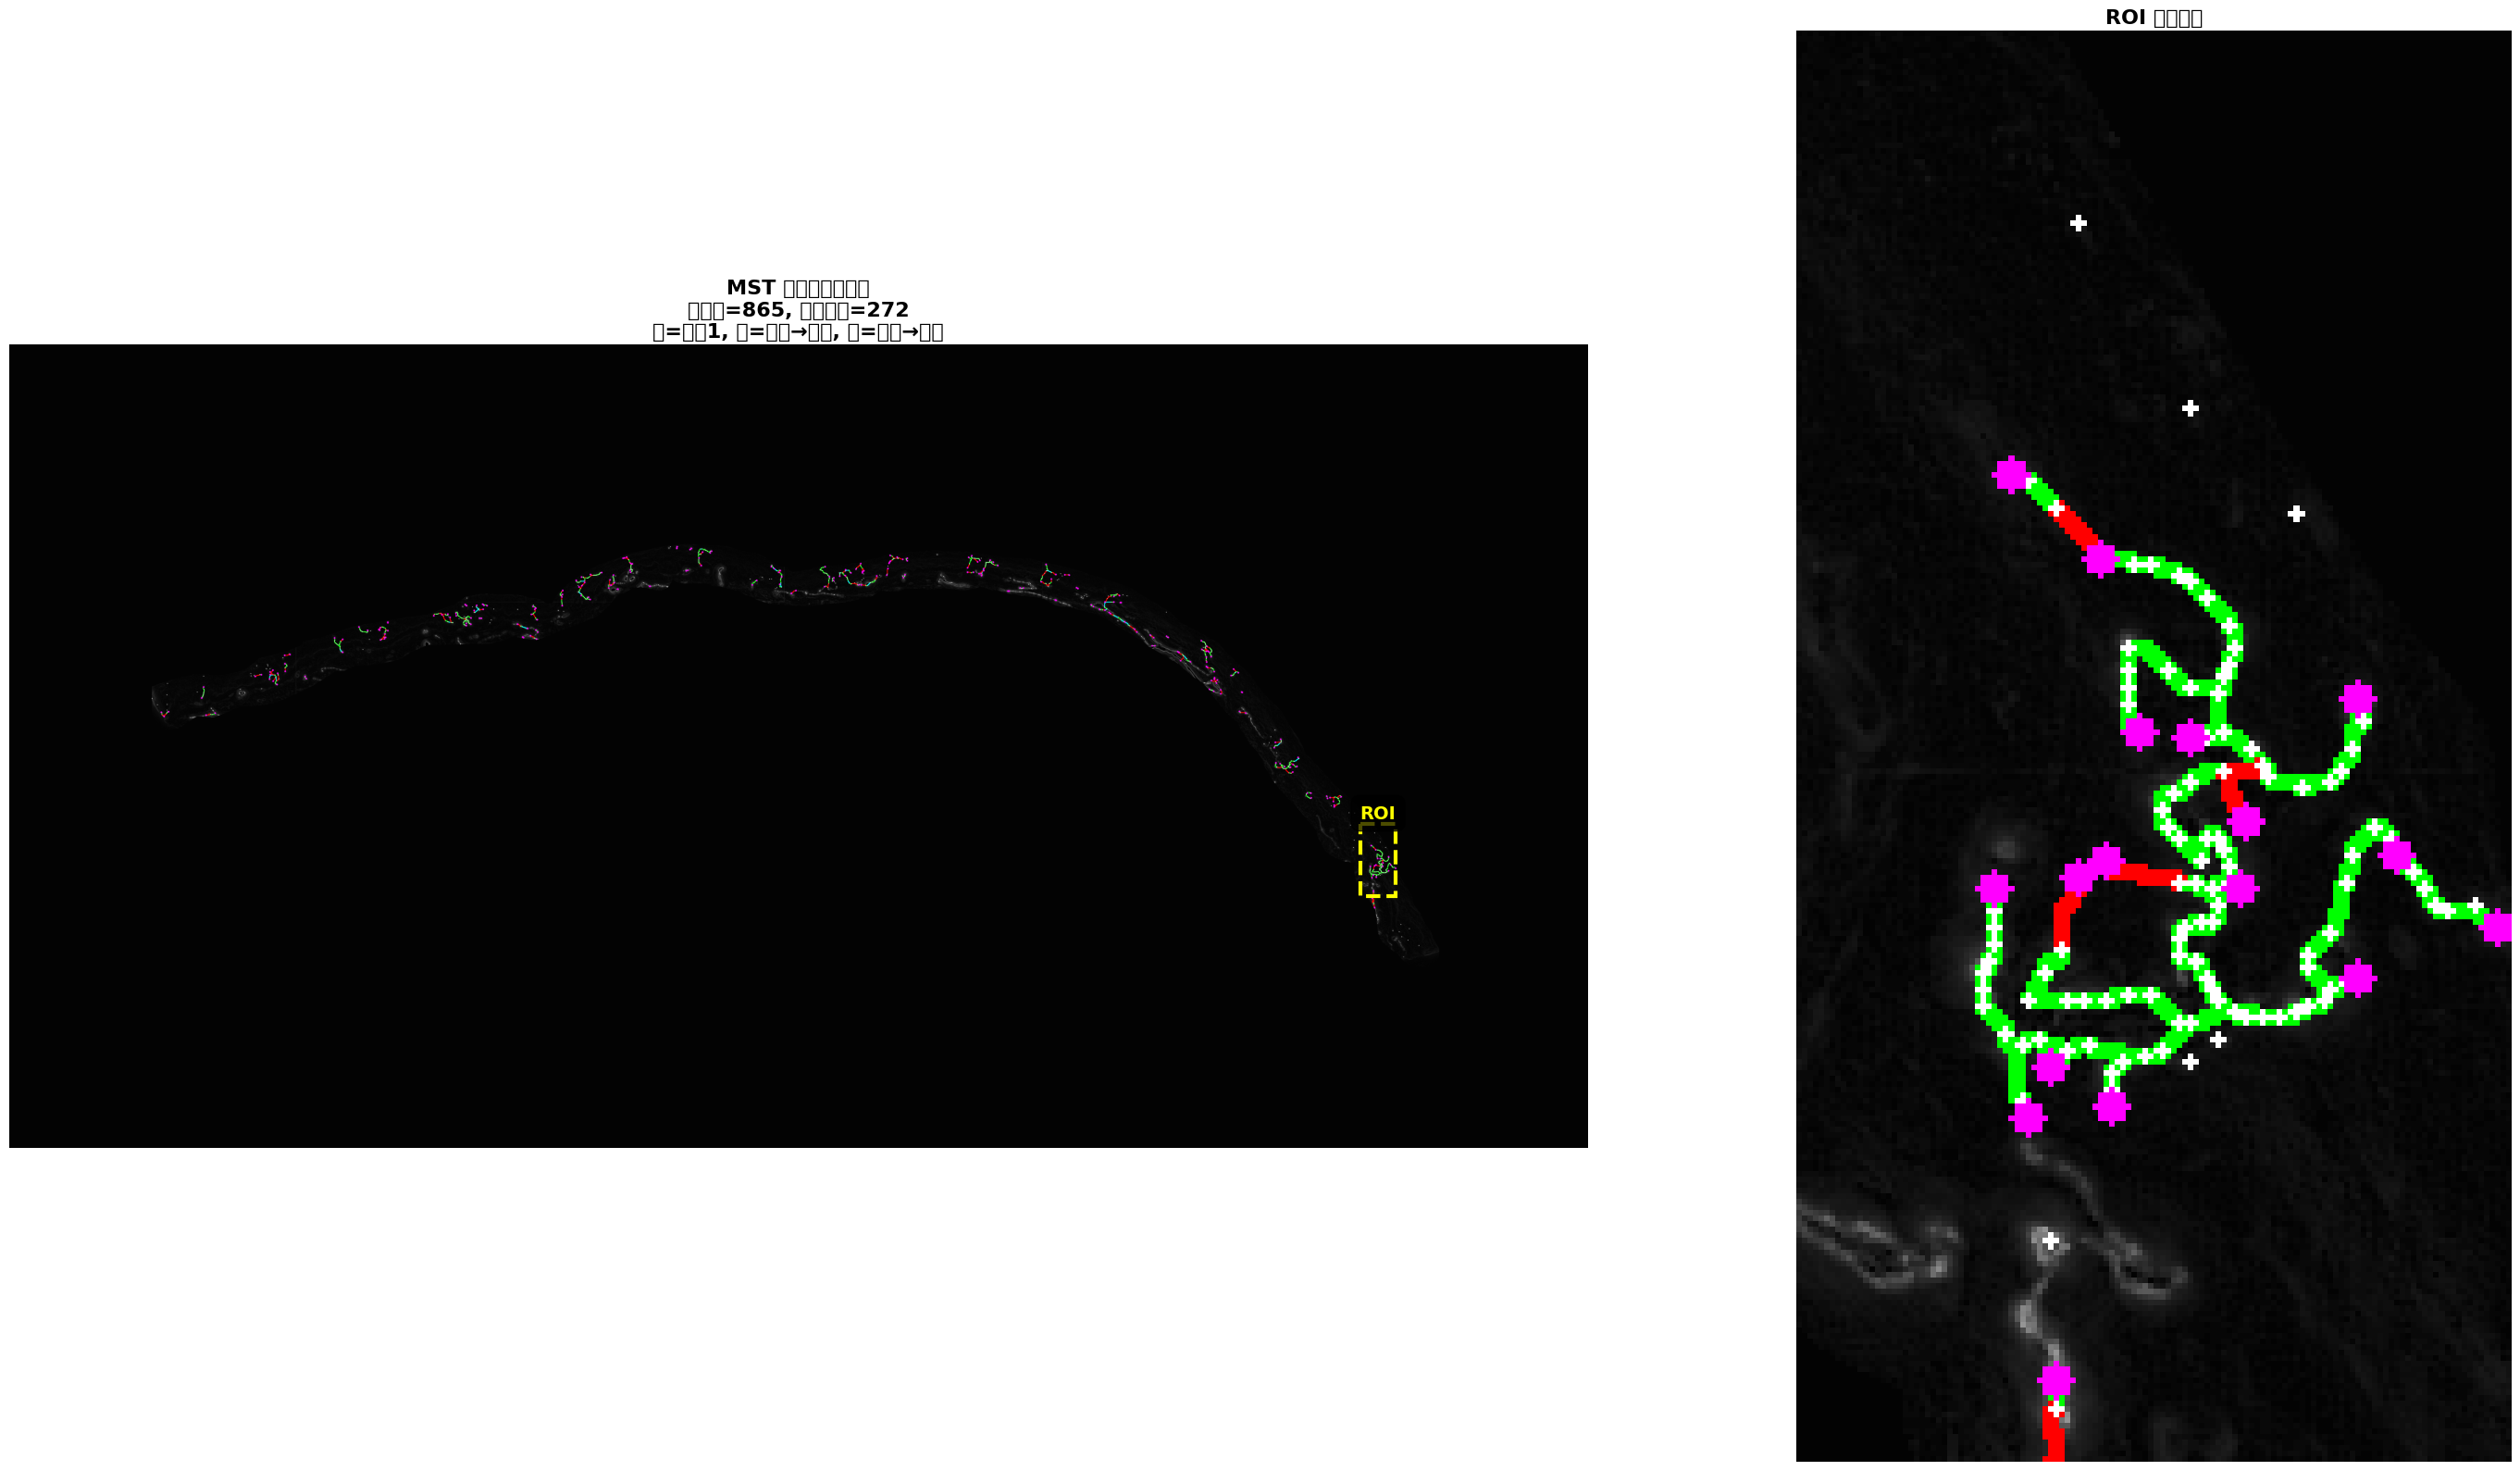


✓ 完整圖像已保存到: ./mst_result_S1585-2_a.png

最終統計:
  - 總節點數: 1086
  - 總邊數: 865
  - 端點數: 272
  - 平均度數: 1.59
  - 連通分量數: 221


In [170]:
# =============================================================================
# 完整圖像可視化
# =============================================================================

print("=" * 60)
print("生成完整圖像可視化")
print("=" * 60)

# 創建完整圖像的視覺化
fig, axes = plt.subplots(1, 2, figsize=(32, 16))

# ============= 左圖：MST 結果（完整圖）=============
ax = axes[0]
viz_img_full = cv2.cvtColor(equalized_img.copy(), cv2.COLOR_GRAY2BGR)

# 繪製 MST 的所有邊
for u, v, data in mst_result.edges(data=True):
    path = data['path']
    
    if data.get('phase') == 1:
        # 階段1的邊（綠色）
        color = (0, 255, 0)  # BGR: Green
        thickness = 2
    else:
        # 階段2的邊
        deg_u = extended_graph.degree(u)
        deg_v = extended_graph.degree(v)
        
        if deg_u == 1 and deg_v == 1:
            color = (255, 255, 0)  # BGR: Cyan
            thickness = 2
        else:
            color = (0, 0, 255)  # BGR: Red
            thickness = 2
    
    # 繪製路徑
    path_array = np.array(path)[:, ::-1]  # 轉換為 (x, y) 順序
    cv2.polylines(viz_img_full, [path_array], isClosed=False, 
                  color=color, thickness=thickness)

# 標記所有種子節點（小圓點）
for node in mst_result.nodes():
    py, px = node
    cv2.circle(viz_img_full, (px, py), radius=1, color=(255, 255, 255), thickness=-1)

# 標記剩餘端點（較大圓點）
endpoints_mst = [n for n in mst_result.nodes() if mst_result.degree(n) == 1]
for ep in endpoints_mst:
    py, px = ep
    cv2.circle(viz_img_full, (px, py), radius=3, color=(255, 0, 255), thickness=-1)

ax.imshow(cv2.cvtColor(viz_img_full, cv2.COLOR_BGR2RGB))
ax.set_title(f'MST 結果（完整圖）\n總邊數={mst_result.number_of_edges()}, 剩餘端點={len(endpoints_mst)}\n綠=階段1, 青=端點→端點, 紅=端點→中間', 
             fontsize=16, fontweight='bold')
ax.axis('off')

# 繪製 ROI 邊界
from matplotlib.patches import Rectangle
rect = Rectangle((ROI_X, ROI_Y), ROI_W, ROI_H, 
                 linewidth=3, edgecolor='yellow', facecolor='none', linestyle='--')
ax.add_patch(rect)
ax.text(ROI_X + ROI_W/2, ROI_Y - 20, 'ROI', 
        fontsize=14, color='yellow', ha='center', weight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='black', alpha=0.7))

# ============= 右圖：ROI 放大 =============
ax = axes[1]
viz_img_roi = viz_img_full[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W].copy()

ax.imshow(cv2.cvtColor(viz_img_roi, cv2.COLOR_BGR2RGB))
ax.set_title(f'ROI 放大視圖', fontsize=16, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.show()

# 保存結果圖像
output_path = f"./mst_result_{IMAGE_ID}.png"
cv2.imwrite(output_path, viz_img_full)
print(f"\n✓ 完整圖像已保存到: {output_path}")

# 統計信息
print(f"\n最終統計:")
print(f"  - 總節點數: {mst_result.number_of_nodes()}")
print(f"  - 總邊數: {mst_result.number_of_edges()}")
print(f"  - 端點數: {len(endpoints_mst)}")
print(f"  - 平均度數: {2 * mst_result.number_of_edges() / mst_result.number_of_nodes():.2f}")
print(f"  - 連通分量數: {nx.number_connected_components(mst_result)}")
